In [1]:
import pandas as pd
import keras
from keras.layers import LSTM, Input, Flatten, Dense, Lambda, Reshape, Activation, ReLU, Dropout
from keras.models import Model, Sequential
from keras import backend as K
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, confusion_matrix, precision_score, recall_score
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, f1_score

import seaborn as sns

In [3]:
# Cargar el dataset
# Ficheros V1
file_train = r"C:\Users\Usuario\Desktop\TFM\LSTM2\datos\OLD\datos_entrenamiento_serie_sat3.xlsx"
file_test = r"C:\Users\Usuario\Desktop\TFM\LSTM2\datos\OLD\datos_validacion_serie_sat3.xlsx"

# Ficheros V2
#file_train = r"C:\Users\Usuario\Desktop\LSTM2\datos\N\N_datos_entrenamiento_serie_sat3.xlsx"
#file_test = r"C:\Users\Usuario\Desktop\LSTM2\datos\N\N_datos_validacion_serie_sat3.xlsx"

X_train = pd.read_excel(file_train, sheet_name = "Sheet1", index_col = 0)
X_test = pd.read_excel(file_test, sheet_name = "Sheet1", index_col = 0)

In [4]:
# Preparar los datos de entrenamiento
X_train = X_train[X_train.anomaly == 0]  ## Usaremos únicamente la clase 0 (transacciones normales)
Y_train = X_train['anomaly'] #identificación de si los datos de train son anómalos o no
X_train = X_train.drop(columns = ["anomaly"], axis=1)
X_train_columns = X_train.columns
X_train = X_train.values

# Preparar los datos de test
Y_test = X_test['anomaly'] #identificación de si los datos de test son anómalos o no
X_test = X_test.drop(columns = ["anomaly"], axis=1)
X_test_columns = X_test.columns
X_test = X_test.values
X_test = X_test.reshape(1, X_test.shape[0], X_test.shape[1])

In [5]:
print(X_train.shape, X_test.shape, Y_train.shape)
indices = np.arange(len(X_train))
print(indices.shape)

(2006, 30) (1, 1003, 30) (2006,)
(2006,)


In [6]:
# Dividimos los datos: 50% train, 50% validación
train_size1 = int(len(X_train) * 0.5)

# Split into training and test sets
if len(X_train)%2 == 0:
    X_val = X_train[train_size1:]
    Y_val = Y_train[train_size1:]
else:
    X_val = X_train[train_size1+1:]
    Y_val = Y_train[train_size1+1:]
    
X_train = X_train[:train_size1]
Y_train = Y_train[:train_size1]

In [7]:
X_train = X_train.reshape(1, X_train.shape[0], X_train.shape[1])
X_val = X_val.reshape(1, X_val.shape[0], X_val.shape[1])

In [9]:
# Definimos la arquitectura del modelo
model = tf.keras.models.Sequential([
  tf.keras.layers.LSTM(64, return_sequences=True),
  tf.keras.layers.LSTM(64, return_sequences=False),
  tf.keras.layers.RepeatVector(X_train.shape[1]),
  tf.keras.layers.LSTM(64, return_sequences=True),
  tf.keras.layers.LSTM(64, return_sequences=True),
  tf.keras.layers.TimeDistributed(Dense(X_train.shape[2], activation='sigmoid')),
])

# Compilamos el modelo
model.compile(keras.optimizers.Adam(learning_rate=0.001), loss='mean_squared_error')

In [11]:
X_train.shape

(1, 1003, 30)

In [239]:
# Definicion de early_stopping
early_stopping = EarlyStopping(monitor='val_loss',
                               patience=5,
                               restore_best_weights=True)

In [240]:
##### Entrenamos el modelo
model.fit(X_train,X_train,verbose=1,epochs=50, batch_size=32, validation_data=(X_val, X_val), callbacks=[early_stopping])

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 41s 41s/step - loss: 0.1763 - val_loss: 0.1684
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step - loss: 0.1687 - val_loss: 0.1592
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - loss: 0.1599 - val_loss: 0.1482
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - loss: 0.1494 - val_loss: 0.1365
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - loss: 0.1381 - val_loss: 0.1253
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step - loss: 0.1270 - val_loss: 0.1153
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step - loss: 0.1170 - val_loss: 0.1068
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - loss: 0.1083 - val_loss: 0.0995
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - loss: 0.1009 - val_loss: 0.0933
Epoch 10/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step - loss: 0.0946 - val_loss: 0.0878
Epoch 11/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step - loss: 0.0890 - val_loss: 0.0830
Epoch 12/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - loss: 0.0842 - val_los

## Creamos el umbral para la identificación de anomalías

In [265]:
# Definimos un umbral a través del cual si una reconstrucción tiene un error superior a este, el modelo clasifica este ítem como anomalía
pred = model.predict(X_val)
ecm=np.mean(np.power(X_val-pred, 2), axis=1)
umbral = 75
umbral_fijo=np.percentile(ecm, umbral)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


## Evaluamos el modelo

In [266]:
reconstructed_test = model.predict(X_test)
ecm_test=np.mean(np.power(X_test-reconstructed_test, 2), axis=2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


In [267]:
Y_pred_test = [1 if e > umbral_fijo else 0 for e in ecm_test[0]]
conf_matrix = confusion_matrix(Y_test, Y_pred_test)
print(conf_matrix)

[[434 418]
 [ 24 127]]


In [268]:
precision = precision_score(Y_test, Y_pred_test)
recall = recall_score(Y_test, Y_pred_test)
f1 = f1_score(Y_test, Y_pred_test)
print(round(precision, 3), round(recall, 3), round(f1, 3))

0.233 0.841 0.365


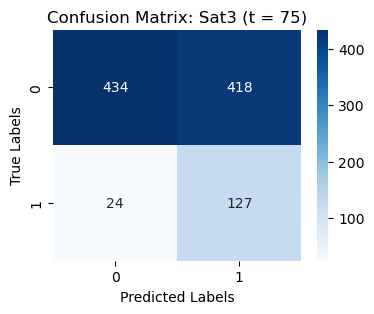

In [269]:
plt.figure(figsize=(4, 3))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title(f'Confusion Matrix: Sat3 (t = {umbral})')
plt.show()

### NO USADO

In [11]:
# Calcular la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, mse)
roc_auc = auc(fpr, tpr)

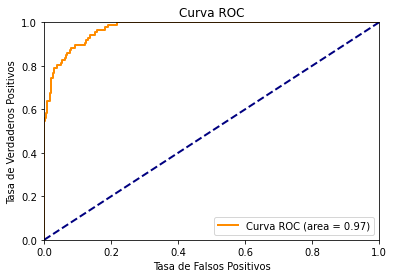

In [96]:
# Graficar la curva ROC
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='Curva ROC (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC')
plt.legend(loc="lower right")
plt.show()

In [233]:
ecm=np.power(X_test-reconstructed_test, 2)

In [237]:
anomaly_index=[datos_validacion.index[i] for i in range(datos_validacion.shape[0]) if datos_validacion['anomaly'][i]==1]
normal_index=[datos_validacion.index[i] for i in range(datos_validacion.shape[0]) if datos_validacion['anomaly'][i]==0]
ecm_anomaly=[ecm[:,23][i] for i in anomaly_index]
ecm_normal=[ecm[:,23][i] for i in normal_index]
time_test_anomaly=[time_test[i] for i in anomaly_index]
time_test_normal=[time_test[i] for i in normal_index]
print(max(ecm_anomaly), max(ecm_normal))

0.6239611297570089 0.606471260035691


In [238]:
matriz1 = pd.DataFrame(np.column_stack((ecm_anomaly, time_test_anomaly)), columns = ['error_reconstruccion', 'time'])
matriz2 = pd.DataFrame(np.column_stack((ecm_normal, time_test_normal)), columns = ['error_reconstruccion', 'time'])
matriz3 = pd.DataFrame(np.column_stack((ecm[:,23], time_test)), columns = ['error_reconstruccion', 'time']) 

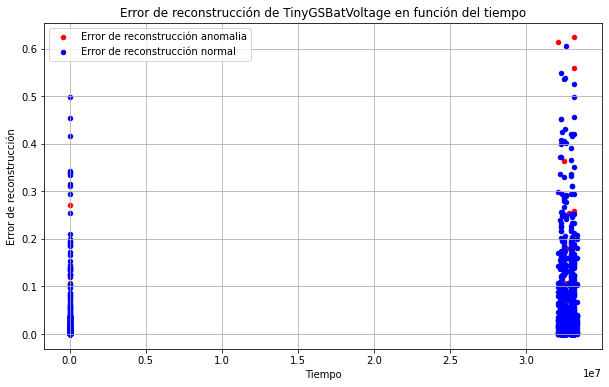

In [239]:
plt.figure(figsize=(10, 6))
plt.scatter(matriz1['time'], matriz1['error_reconstruccion'], label='Error de reconstrucción anomalia', color='red', s=20)
plt.scatter(matriz2['time'], matriz2['error_reconstruccion'], label='Error de reconstrucción normal', color='blue', s=20)
plt.xlabel('Tiempo')
plt.ylabel('Error de reconstrucción')
plt.title('Error de reconstrucción de TinyGSBatVoltage en función del tiempo')
plt.legend()
plt.grid(True)
plt.show()

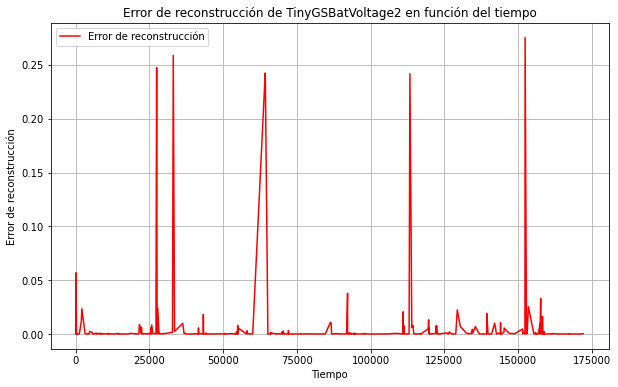

In [202]:
plt.figure(figsize=(10, 6))
plt.plot(matriz['time'], matriz['error_reconstruccion'], label='Error de reconstrucción', color='red')
plt.xlabel('Tiempo')
plt.ylabel('Error de reconstrucción')
plt.title('Error de reconstrucción de TinyGSBatVoltage2 en función del tiempo')
plt.legend()
plt.grid(True)
plt.show()

In [84]:
df_normal = datos_validacion[normal_mask]
df_anomaly = datos_validacion[anomaly_mask]

<BarContainer object of 86 artists>

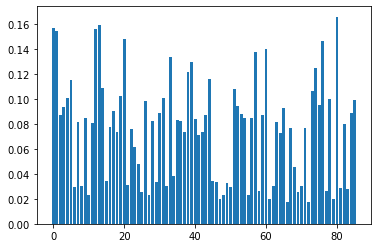

In [86]:
plt.bar(range(df_normal.shape[0]), ecm[normal_mask])
plt.bar(range(df_anomaly.shape[0]), ecm[anomaly_mask])